In [1]:
import torch
import torch.nn.functional as F
import torch.nn as nn
# import torch.optim as optim
# import torch_optimizer as optim
import torch.nn.init as init
import adabound
import matplotlib.pyplot as plt
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
import pandas as pd
import numpy as np
import math

from tqdm import tqdm
from tqdm import trange

C:\Users\KIST3\AppData\Roaming\Python\Python37\site-packages\tqdm\auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/zorocrit/Control_Nuclear_Spins/master/initialize13Cspin/fixed_testdata.csv?token=GHSAT0AAAAAAB5HMDTBJUHU5GSRFHQWKZWCZABI5BA')
# df

In [3]:
# y = df[['x', 'N', 'z']]
# # y

y = df[['Xtau', 'XN', 'Ztau', 'ZN']]
y

,Xtau,XN,Ztau,ZN
0,1.355255,5.0,0.092347,5.0
1,2.601582,9.0,1.599869,13.0
2,1.528623,9.0,0.374334,5.0
3,1.595862,9.0,0.989839,13.0
4,0.517431,13.0,0.233642,9.0
...,...,...,...,...
1592,3.022292,9.0,1.295029,13.0
1593,3.975000,17.0,0.198750,9.0
1594,2.835303,9.0,2.257162,9.0
1595,2.945992,9.0,0.148853,13.0


In [4]:
X = df[['Al', 'Ap']]
# X

In [5]:
Xdata = list(np.array(X.values.tolist()))
# print(Xdata)

In [6]:
ydata = list(np.array(y.values.tolist()))
# print(ydata)

In [7]:
torch.manual_seed(1)

In [8]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# for reproducibility
torch.manual_seed(777)
if device == 'cuda':
    torch.cuda.manual_seed_all(777)

In [9]:
x = torch.FloatTensor(Xdata).to(device)
y = torch.FloatTensor(ydata).to(device)

C:\Users\KIST3\AppData\Roaming\Python\Python37\site-packages\ipykernel_launcher.py:1: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at  C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\torch\csrc\utils\tensor_new.cpp:204.)
  """Entry point for launching an IPython kernel.


In [37]:
num_data = 1597

num_epoch = 200000

  0%|          | 15/200000 [00:00<22:22, 148.91it/s]

Case 0, Loss: tensor(5.6183, device='cuda:0')


  5%|▌         | 10027/200000 [00:55<17:39, 179.25it/s]

Case 10000, Loss: tensor(1.6714, device='cuda:0')


 10%|█         | 20034/200000 [01:51<16:44, 179.13it/s]

...

Case 180000, Loss: tensor(0.1582, device='cuda:0')


 95%|█████████▌| 190028/200000 [17:43<00:55, 178.80it/s]

Case 190000, Loss: tensor(0.1331, device='cuda:0')


100%|██████████| 200000/200000 [18:39<00:00, 178.59it/s]


tensor(0.1206, device='cuda:0')
[Parameter containing:
tensor([[-1.1280e+00, -1.8279e+00],
        [-5.3692e-02, -6.2270e-01],
        [ 2.5867e+00, -1.5278e+01],
        [ 1.1584e-02, -6.0360e-01],
        [-5.0625e+00,  1.6416e+00],
        [ 4.8737e+00, -4.2810e+00],
        [-5.2540e-02, -4.4547e-01],
        [-7.9296e+00,  6.6684e+00],
        [-1.7416e-01,  1.4502e+01],
        [-2.3667e+00,  7.0350e+00]], device='cuda:0', requires_grad=True), Parameter containing:
tensor([ 1.7728,  0.1256,  6.4373,  0.0630, 17.2918, -1.0265, -0.2420,  2.0381,
        -8.6612,  6.6615], device='cuda:0', requires_grad=True), Parameter containing:
tensor([[ 9.9872e-02, -2.1949e-01,  1.3261e+00,  1.7512e-01,  4.2758e-01,
          1.7231e-01,  1.7319e-01, -1.2407e+00, -3.8648e-01, -4.3712e-02],
        [-2.4589e-01,  1.7581e-01, -1.2096e-02,  1.0435e-01, -5.0151e-02,
         -2.8545e-01,  4.8502e-02,  3.9825e-02, -1.7726e-01, -1.5033e-01],
        [ 8.3466e-01, -2.1301e-01,  1.1767e+00, -3.0975e-01

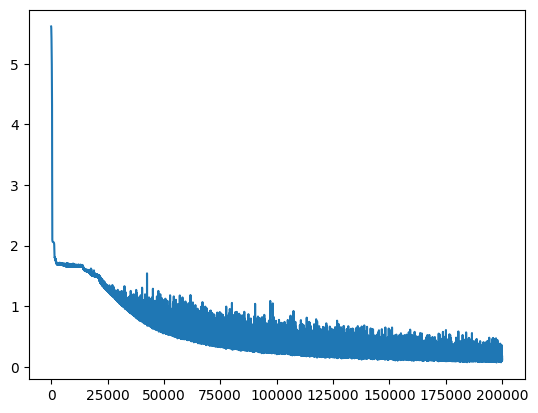

In [38]:
model = nn.Sequential(

    nn.Linear(2,10),

    nn.ReLU(),

    nn.Linear(10,40),

    nn.ReLU(),

    nn.Linear(40,55),

    nn.ReLU(),

    nn.Linear(55,80),

    nn.ReLU(),

    nn.Linear(80,120),

    nn.ReLU(),

    nn.Linear(120,150),

    nn.ReLU(),

    nn.Linear(150,130),

    nn.ReLU(),

    nn.Linear(130,110),

    nn.ReLU(),

    nn.Linear(110,95),

    nn.ReLU(),

    nn.Linear(95,70),

    nn.ReLU(),

    nn.Linear(70,30),

    nn.ReLU(),

    nn.Linear(30,4)

).to(device)

#ReLU라는 Activation Function을 사용하여, 4개의 Linear Layer로 모델 구현

# Input layer에 1개씩 데이터가 들어가므로 nn.Linear(1,2)이며, 최종적으로 1개의 값이 나와야하기에 Output Layer는 nn.Linear(4,1)

 

loss_func = nn.L1Loss().to(device)

# optimizer = optim.SGD(model.parameters(),lr = 0.0002)

optimizer = adabound.AdaBound(model.parameters(), lr=1.135 * 1e-5, final_lr=0.07112)

loss_array = []


for i in tqdm(range(num_epoch)) : 

    optimizer.zero_grad()

    output = model(x)

    loss = loss_func(output,y)

    loss.backward()

    optimizer.step()

 

    loss_array.append(loss)

    if(i%10000 == 0):
      print("Case "+ str(i) + ", Loss: " + str(loss.data))
    
    if i == num_epoch - 1:

        print(loss.data)

        param_list = list(model.parameters())

        #최종 학습된 마지막 결과물의 Parameter 저장

        print(param_list)

loss_array = torch.tensor(loss_array)

loss_array.detach().numpy()

plt.plot(loss_array)

plt.show()

#Loss(y_predicted - y_real)값이 어떻게 변하는지 그래프로 도식화

In [41]:
# 임의의 입력 [73, 80, 75]를 선언
new_var =  torch.FloatTensor([[4.493041, 0.5427]]).to(device)
# 입력한 값 [73, 80, 75]에 대해서 예측값 y를 리턴받아서 pred_y에 저장
pred_y = model(new_var) 
print("훈련 후 예측값 :", pred_y) 

훈련 후 예측값 : tensor([[ 3.4563, 16.9313,  1.2362, 14.3154]], device='cuda:0',
       grad_fn=<AddmmBackward0>)
